In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

## Load the Iris Data

In [4]:
from sklearn.datasets import load_iris
iris = load_iris()

X , y = iris.data , iris.target

In [7]:
# train test split 
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [8]:
from sklearn.tree import DecisionTreeClassifier , plot_tree

## Full tree (no pruning)

In [9]:
clf_full = DecisionTreeClassifier(random_state = 42)
clf_full.fit(X_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
from sklearn.metrics import accuracy_score

print(f"accuracy on train data: {accuracy_score(y_train , clf_full.predict(X_train))}")
print(f"accuracy on test data: {accuracy_score(y_test , clf_full.predict(X_test))}")

accuracy on train data: 1.0
accuracy on test data: 1.0


In [11]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf_full, X, y, cv=5)
print(f"Cross-validation scores: {scores}")
print(f"Mean accuracy: {scores.mean():.4f}")

Cross-validation scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Mean accuracy: 0.9533


## Visualize the Full Tree

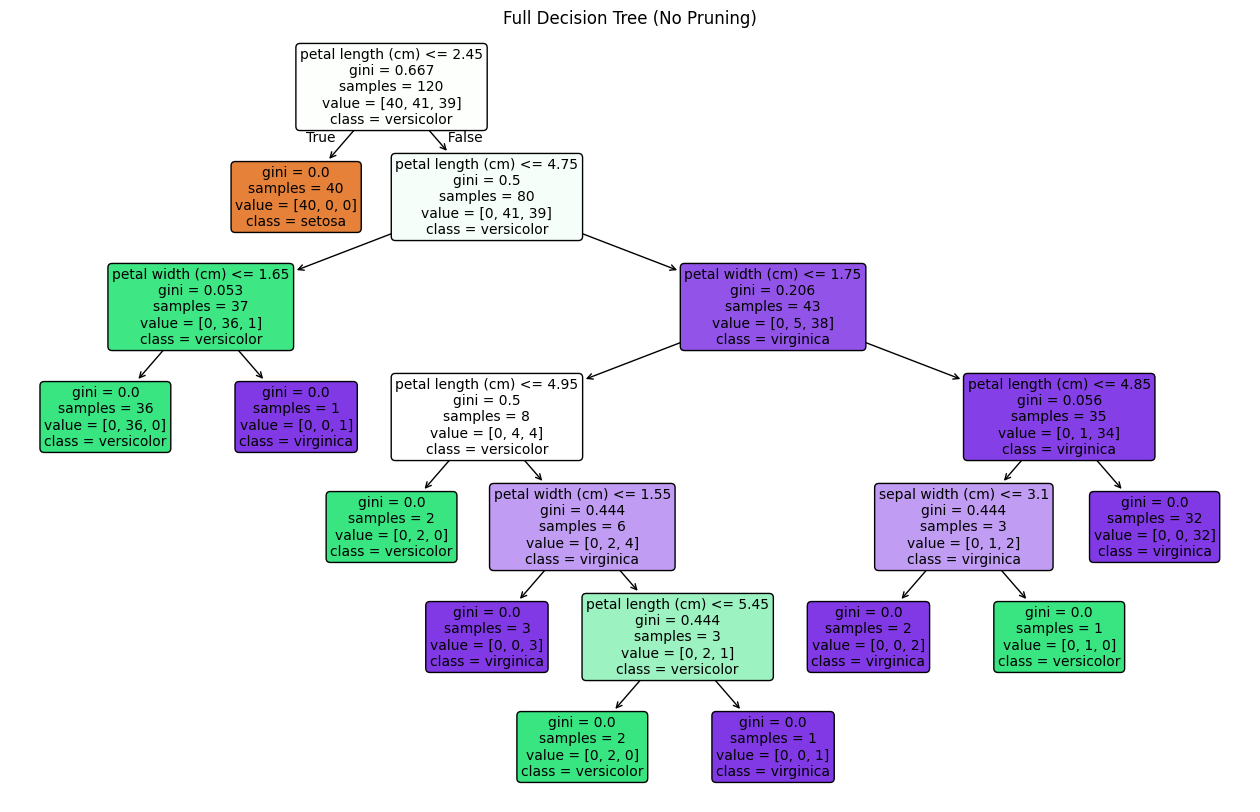

In [12]:
plt.figure(figsize = (16 , 10))
plot_tree(
    clf_full, 
    filled = True,
    feature_names = iris.feature_names, 
    class_names = iris.target_names, 
    rounded = True
)
plt.title("Full Decision Tree (No Pruning)")
plt.show()

## Post Pruning(Cost Complexity Pruning)

### Model Training with post pruning

--- 
 1. Get the pruning path (list of possible ccp_alpha values).
 2. Train trees for each ccp_alpha.
 3. Select the best tree using a validation set.
 4. Visualize the pruned tree.

In [13]:
# step-1: get cost complexity pruning path  
path = clf_full.cost_complexity_pruning_path(X_train , y_train)

ccp_alphas , impurities = path.ccp_alphas , path.impurities

print(f"Total alphas to try: {len(ccp_alphas)}")

Total alphas to try: 8


In [14]:
# Step 2: Train a Tree for Each Alpha
all_models = []

for alpha in ccp_alphas: 
    model = DecisionTreeClassifier(random_state = 42 , ccp_alpha = alpha)
    model.fit(X_train , y_train)
    all_models.append(model)

In [15]:
# Step 3: Evaluate Each Tree on Train and Test Data 
train_scores = [accuracy_score(y_train , model.predict(X_train)) for model in all_models]
test_scores = [accuracy_score(y_test , model.predict(X_test)) for model in all_models]

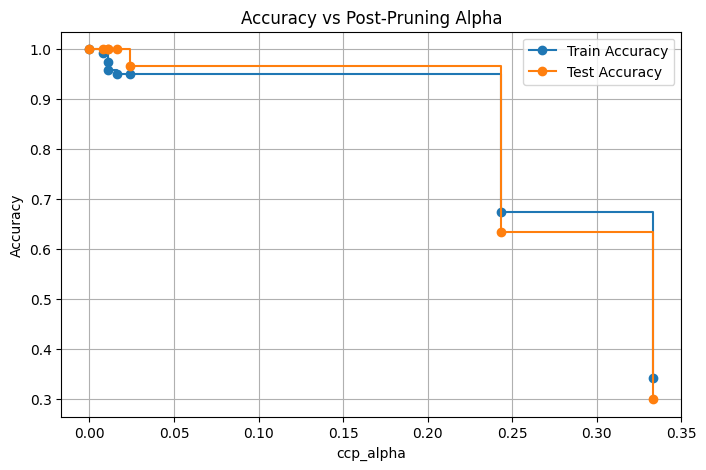

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(ccp_alphas, train_scores, marker='o', label='Train Accuracy', drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker='o', label='Test Accuracy', drawstyle="steps-post")

plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Post-Pruning Alpha")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
# Step 5: Pick the Best Model (Highest Test Accuracy) 
best_index = np.argmax(test_scores)
best_alpha = ccp_alphas[best_index]
best_model = all_models[best_index]

print(f"Best alpha: {best_alpha:.5f}")
print(f"Test Accuracy: {test_scores[best_index]:.4f}")

Best alpha: 0.00000
Test Accuracy: 1.0000


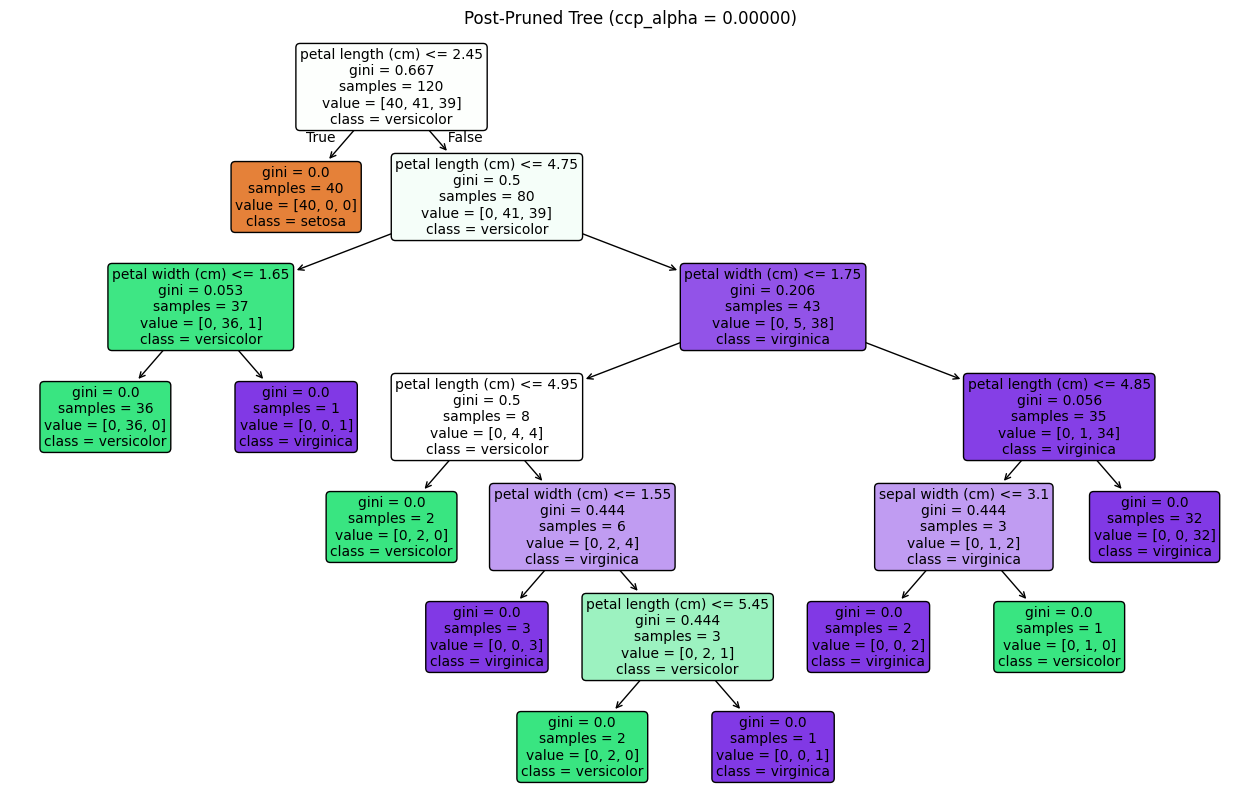

In [19]:
# Step 6: Visualize the Post Pruned Tree
plt.figure(figsize=(16, 10))

plot_tree(
    best_model,
    filled = True,
    feature_names = iris.feature_names,
    class_names = iris.target_names,
    rounded = True
)
plt.title(f"Post-Pruned Tree (ccp_alpha = {best_alpha:.5f})")
plt.show()

## Pre-pruning(Early Stopping)

In [20]:
parameter = {
    'criterion' : ['gini', 'entropy', 'log_loss'], 
    'splitter' : ['best' , 'random'], 
    'max_depth' : [1 , 2 , 3 , 4 , 5], 
    'max_features' : [None , 'sqrt' , 'log2'], 
    'ccp_alpha' : [1 , 2 , 3 , 4 , 5]
}

In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
decision_model = DecisionTreeClassifier()

cv = GridSearchCV(decision_model ,
                  param_grid = parameter, 
                  cv = 5 , scoring = 'accuracy'
                 )

In [23]:
cv.fit(X_train , y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'ccp_alpha': [1, 2, ...], 'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': [None, 'sqrt', ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [24]:
cv.best_params_

{'ccp_alpha': 1,
 'criterion': 'gini',
 'max_depth': 1,
 'max_features': None,
 'splitter': 'best'}

In [27]:
y_pred = cv.predict(X_test)

accuracy_score(y_test , y_pred)

0.3